In [1]:
import pandas as pd
import geopandas as gpd
from google.colab import drive
from shapely.geometry import Point
import matplotlib.pyplot as plt
import math

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# load in the journey counts dataset


counts_path = '/content/drive/MyDrive/journey_counts_300m.csv'
counts_df = pd.read_csv(counts_path)

print("\nFiltered Counts:")
print("Shape:", counts_df.shape)
display(counts_df.head())


Filtered Counts:
Shape: (489925, 8)


,JOURNEY_LINK_ID,DATE_TIME,TOTAL_MATCHES,JOURNEY_TIME,JOURNEY_LINK,JOURNEY_START,JOURNEY_END,SPEED
0,72,2023/07/17 20:00:00+00,49,292.14,Bond St WB > Queens Rd OB,Bond St WB,Queens Rd OB,14.72
1,74,2023/03/17 08:00:00+00,225,214.37,Bond St WB > Anchor Rd OB,Bond St WB,Anchor Rd OB,13.82
2,184,2023/01/13 22:00:00+00,111,250.47,Easton Way SB > Bath Rd/Kings Rd SB,Easton Way SB,Bath Rd/Kings Rd SB,26.09
3,60,2023/01/29 02:00:00+00,3,747.00,Old Market IB > Bedminster Bridge,Old Market IB,Bedminster Bridge,6.36
4,148,2023/03/09 08:00:00+00,31,407.77,Queens Rd IB > Bond St EB,Queens Rd IB,Bond St EB,10.05


In [4]:
# split the date and time column
counts_df['DATE'] = pd.to_datetime(counts_df['DATE_TIME']).dt.date
counts_df['TIME'] = pd.to_datetime(counts_df['DATE_TIME']).dt.time
counts_df = counts_df.drop(columns='DATE_TIME')


In [5]:
# do a statistical summary for every journey link ID + total matches
print(f'statistical summary for total matches : {counts_df.groupby('JOURNEY_LINK_ID')['TOTAL_MATCHES'].describe()}')
print(f'statistical summary for journey time : {counts_df.groupby('JOURNEY_LINK_ID')['JOURNEY_TIME'].describe()}')
print(f'statistical summary for journey speed : {counts_df.groupby('JOURNEY_LINK_ID')['SPEED'].describe()}')

statistical summary for total matches :                   count        mean         std  min   25%    50%    75%  \
JOURNEY_LINK_ID                                                            
3                1775.0    4.587606    2.946931  3.0   3.0    3.0    6.0   
6                2283.0    4.309680    2.191336  3.0   3.0    3.0    6.0   
7                4949.0   11.789250   13.803207  3.0   3.0    7.0   13.0   
9                8184.0   34.638319   26.030776  3.0  14.0   28.0   51.0   
10               4305.0   17.485250   14.378507  3.0   6.0   13.0   24.0   
...                 ...         ...         ...  ...   ...    ...    ...   
227              7862.0  180.431570  120.939306  3.0  71.0  174.0  284.0   
228              1015.0    4.170443    2.534090  3.0   3.0    3.0    4.0   
229                96.0    3.093750    0.412390  3.0   3.0    3.0    3.0   
230              5287.0  118.005863   71.649741  3.0  55.0  122.0  177.0   
233                99.0    3.696970    1.716989 

In [6]:
# look for missing data
counts_df.isnull().sum()

,0
JOURNEY_LINK_ID,0
TOTAL_MATCHES,0
JOURNEY_TIME,0
JOURNEY_LINK,0
JOURNEY_START,0
JOURNEY_END,0
SPEED,0
DATE,0
TIME,0


In [8]:
counts_df['JOURNEY_LINK_ID'].value_counts().sort_values()

,count
JOURNEY_LINK_ID,
38,1
27,2
37,3
135,8
223,9
...,...
200,8670
74,8813
157,8976


In [7]:
# look at the temporal spread
# Ensure correct types
counts_df['DATE'] = pd.to_datetime(counts_df['DATE'])

# Temporal spread per JOURNEY_LINK_ID
temporal_spread = counts_df.groupby('JOURNEY_LINK_ID').agg(
    distinct_dates=('DATE', 'nunique'),
    distinct_hours=('TIME', 'nunique'),
    distinct_days_of_week=('DATE', lambda x: x.dt.dayofweek.nunique()),
    distinct_months=('DATE', lambda x: x.dt.month.nunique())
).reset_index()

temporal_spread.sort_values('distinct_dates').head(20)



,JOURNEY_LINK_ID,distinct_dates,distinct_hours,distinct_days_of_week,distinct_months
20,38,1,1,1,1
16,27,2,2,2,2
19,37,3,3,3,3
71,135,8,7,6,5
123,223,9,7,5,6
116,209,9,6,6,6
32,57,11,7,5,5
18,30,15,9,6,8
126,226,15,11,6,6
40,67,16,8,7,6


In [9]:
temporal_spread[temporal_spread['distinct_months'] < 7].sort_values('distinct_months')

,JOURNEY_LINK_ID,distinct_dates,distinct_hours,distinct_days_of_week,distinct_months
20,38,1,1,1,1
16,27,2,2,2,2
19,37,3,3,3,3
32,57,11,7,5,5
71,135,8,7,6,5
40,67,16,8,7,6
116,209,9,6,6,6
123,223,9,7,5,6
126,226,15,11,6,6


In [10]:
# remove all the rows with 2024
counts_df = counts_df[pd.to_datetime(counts_df['DATE']).dt.year != 2024]

print(f"Remaining rows: {len(counts_df)}")
print(f"Years remaining: {pd.to_datetime(counts_df['DATE']).dt.year.unique()}")

Remaining rows: 408212
Years remaining: [2023]


Journey link IDs with all 24 hours: 86


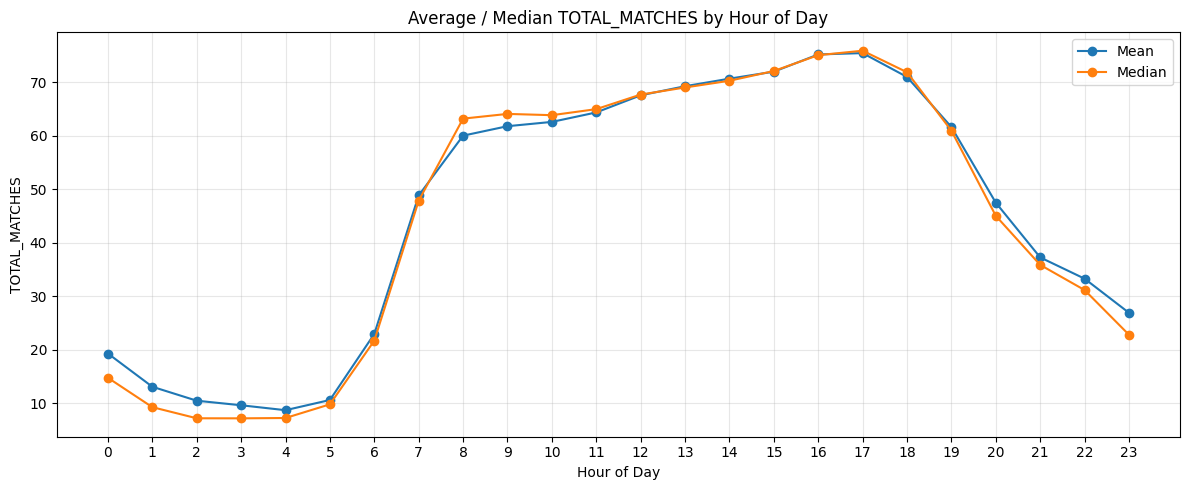

In [11]:
counts_df['HOUR'] = counts_df['TIME'].apply(lambda x: x.hour)

hours_per_link = counts_df.groupby('JOURNEY_LINK_ID')['HOUR'].apply(set).reset_index(name='hours')

all_hours = set(range(24))
complete_links = hours_per_link[hours_per_link['hours'].apply(lambda x: all_hours.issubset(x))]

print(f"Journey link IDs with all 24 hours: {len(complete_links)}")

# Filter to only journey link IDs with all 24 hours
counts_df_complete = counts_df[counts_df['JOURNEY_LINK_ID'].isin(complete_links['JOURNEY_LINK_ID'])]

# Aggregate average and median TOTAL_MATCHES per journey link ID and hour
hourly_agg = counts_df_complete.groupby(['JOURNEY_LINK_ID', 'HOUR'])['TOTAL_MATCHES'].agg(['mean', 'median']).reset_index()

# Average across all journey link IDs per hour
hourly_summary = hourly_agg.groupby('HOUR')[['mean', 'median']].mean().reset_index()


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hourly_summary['HOUR'], hourly_summary['mean'], label='Mean', marker='o')
ax.plot(hourly_summary['HOUR'], hourly_summary['median'], label='Median', marker='o')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('TOTAL_MATCHES')
ax.set_title('Average / Median TOTAL_MATCHES by Hour of Day')
ax.set_xticks(range(24))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

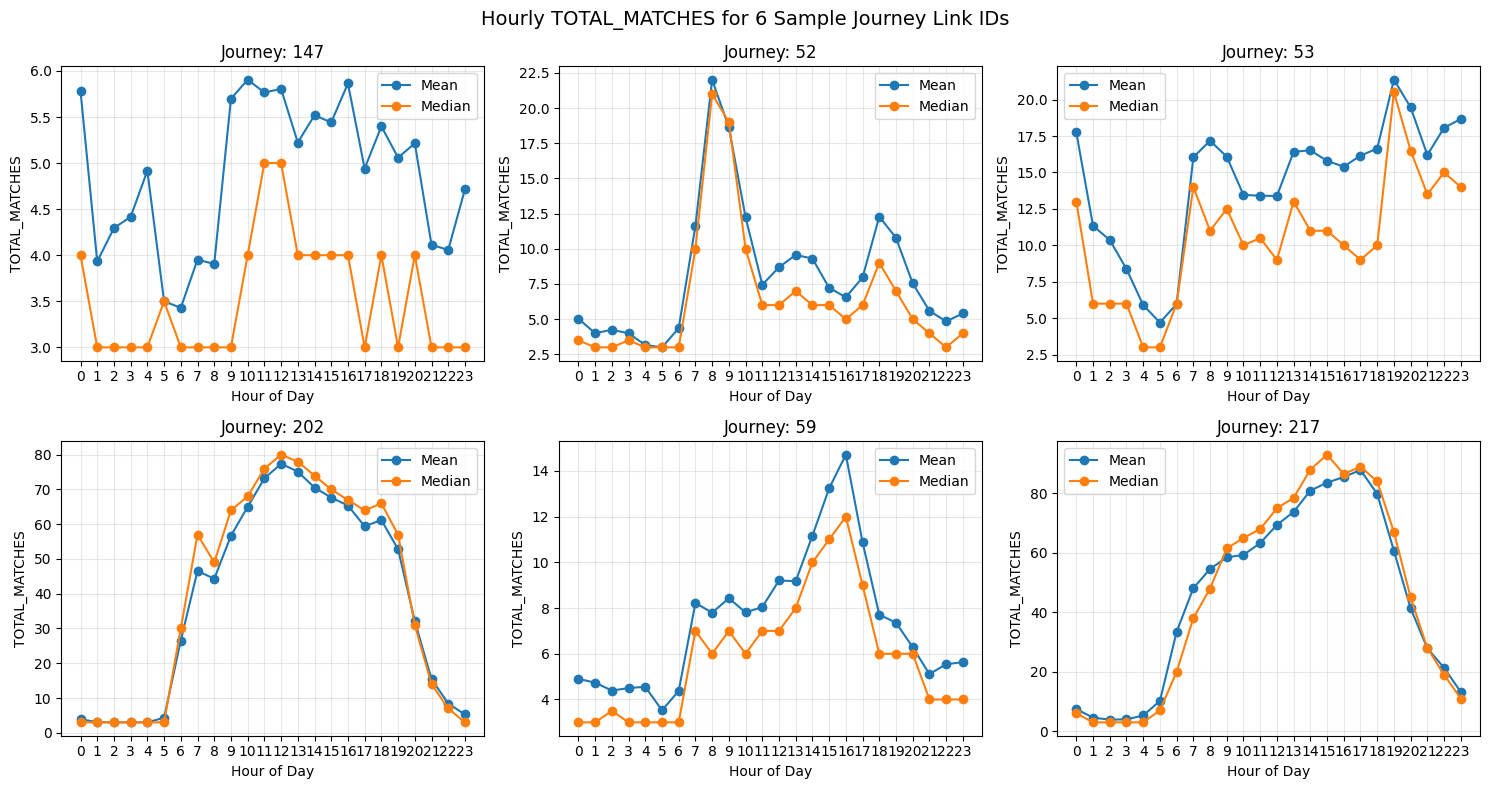

In [12]:
# check if hourly pattern is actually meaningful
# find all the journey link IDs with all 24 hours
# plot the total matches for each journey link ID across the 24 hours
# maybe do some statistical analysis ?

import random

sample_ids = random.sample(list(complete_links['JOURNEY_LINK_ID']), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, journey_id in enumerate(sample_ids):
    group = hourly_agg[hourly_agg['JOURNEY_LINK_ID'] == journey_id]
    axes[i].plot(group['HOUR'], group['mean'], marker='o', label='Mean')
    axes[i].plot(group['HOUR'], group['median'], marker='o', label='Median')
    axes[i].set_title(f'Journey: {journey_id}')
    axes[i].set_xlabel('Hour of Day')
    axes[i].set_ylabel('TOTAL_MATCHES')
    axes[i].set_xticks(range(24))
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Hourly TOTAL_MATCHES for 6 Sample Journey Link IDs', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
from scipy import stats

# Group TOTAL_MATCHES by hour
hourly_groups = [counts_df_complete[counts_df_complete['HOUR'] == h]['TOTAL_MATCHES'].values for h in range(24)]

stat, p_value = stats.kruskal(*hourly_groups)

print(f"Kruskal-Wallis H-statistic: {stat:.4f}")
print(f"P-value: {p_value:.6f}")
print()
if p_value < 0.05:
    print("Result: Significant difference across hours (p < 0.05) — hour does matter for TOTAL_MATCHES")
else:
    print("Result: No significant difference across hours (p >= 0.05) — hour does not matter for TOTAL_MATCHES")

summary_table = counts_df_complete.groupby('HOUR')['TOTAL_MATCHES'].agg(
    count='count',
    mean='mean',
    median='median',
    std='std',
    min='min',
    max='max'
).round(2)

print(f"Kruskal-Wallis H-statistic: {stat:.4f}, P-value: {p_value:.6f}")
print()
print(summary_table.to_string())

Kruskal-Wallis H-statistic: 22851.2561
P-value: 0.000000

Result: Significant difference across hours (p < 0.05) — hour does matter for TOTAL_MATCHES
Kruskal-Wallis H-statistic: 22851.2561, P-value: 0.000000

      count   mean  median     std  min   max
HOUR                                         
0     14411  30.31    13.0   47.69    3   724
1      8651  23.43    10.0   36.52    3   508
2      6766  20.92     9.0   34.20    3   570
3      6153  19.72     8.0   31.15    3   426
4      5825  19.12     9.0   26.14    3   430
5      6941  23.69    10.0   30.43    3   348
6     10195  42.26    15.0   64.60    3   418
7     13498  72.83    29.0  117.66    3   884
8     15786  80.11    32.0  121.79    3   927
9     17082  77.35    31.0  113.96    3   880
10    17698  76.32    31.0  109.39    3   873
11    18041  77.31    32.0  109.54    3   908
12    18313  79.98    33.0  113.96    3   854
13    18448  81.69    34.0  116.53    3   904
14    18414  83.12    35.0  117.50    3   921
15    187

In [14]:
# seperate the time into 6 hour time bins and check the routes that dont have data points in each time bin
# then remove them from counts_df

# Define 6-hour time bins
bins = [0, 6, 12, 18, 24]
labels = ['00-06', '06-12', '12-18', '18-24']

counts_df['TIME_BIN'] = pd.cut(counts_df['HOUR'], bins=bins, labels=labels, right=False)

# Find which bins each journey link ID has
bins_per_link = counts_df.groupby('JOURNEY_LINK_ID')['TIME_BIN'].apply(set).reset_index(name='bins')

# Identify routes missing at least one time bin
all_bins = set(labels)
incomplete_links = bins_per_link[bins_per_link['bins'].apply(lambda x: not all_bins.issubset(x))]

print(f"Total journey link IDs: {bins_per_link['JOURNEY_LINK_ID'].nunique()}")
print(f"Journey link IDs missing at least one 6-hour bin: {len(incomplete_links)}")
print()
print(incomplete_links[['JOURNEY_LINK_ID', 'bins']])

incomplete_link_ids = incomplete_links['JOURNEY_LINK_ID']

counts_df = counts_df[~counts_df['JOURNEY_LINK_ID'].isin(incomplete_link_ids)]

print(f"Removed {len(incomplete_link_ids)} journey link IDs with incomplete time bin coverage")
print(f"Remaining rows: {len(counts_df)}")
print(f"Remaining journey link IDs: {counts_df['JOURNEY_LINK_ID'].nunique()}")


Total journey link IDs: 132
Journey link IDs missing at least one 6-hour bin: 14

     JOURNEY_LINK_ID                   bins
8                 16  {12-18, 18-24, 06-12}
16                27         {12-18, 06-12}
19                37         {12-18, 06-12}
20                38                {12-18}
21                39  {12-18, 18-24, 06-12}
32                57  {12-18, 18-24, 06-12}
40                67         {12-18, 06-12}
65               115  {12-18, 18-24, 06-12}
71               135  {12-18, 18-24, 06-12}
115              208  {12-18, 18-24, 06-12}
121              221  {12-18, 18-24, 06-12}
123              223  {12-18, 18-24, 06-12}
126              226  {12-18, 18-24, 06-12}
131              233  {12-18, 18-24, 06-12}
Removed 14 journey link IDs with incomplete time bin coverage
Remaining rows: 405307
Remaining journey link IDs: 118


Journey link IDs with all 12 months: 85


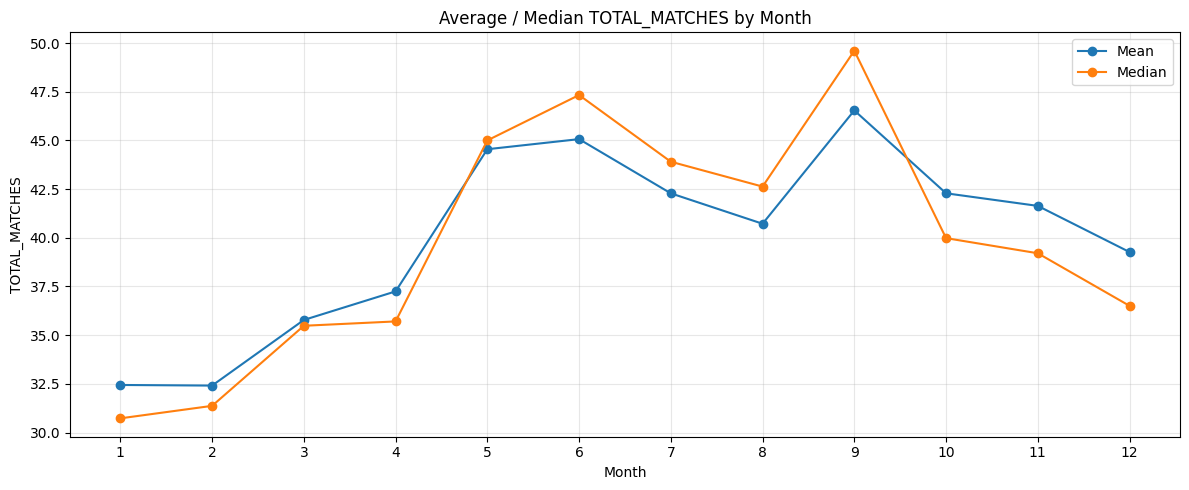

In [15]:
# monthly mean and median plot
counts_df['MONTH'] = counts_df['DATE'].apply(lambda x: x.month)

months_per_link = counts_df.groupby('JOURNEY_LINK_ID')['MONTH'].apply(set).reset_index(name='months')

all_months = set(range(1, 13))
complete_links = months_per_link[months_per_link['months'].apply(lambda x: all_months.issubset(x))]

print(f"Journey link IDs with all 12 months: {len(complete_links)}")

# Filter to only journey link IDs with all 12 months
counts_df_complete = counts_df[counts_df['JOURNEY_LINK_ID'].isin(complete_links['JOURNEY_LINK_ID'])]

# Aggregate average and median TOTAL_MATCHES per journey link ID and month
monthly_agg = counts_df_complete.groupby(['JOURNEY_LINK_ID', 'MONTH'])['TOTAL_MATCHES'].agg(['mean', 'median']).reset_index()

# Average across all journey link IDs per month
monthly_summary = monthly_agg.groupby('MONTH')[['mean', 'median']].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_summary['MONTH'], monthly_summary['mean'], label='Mean', marker='o')
ax.plot(monthly_summary['MONTH'], monthly_summary['median'], label='Median', marker='o')
ax.set_xlabel('Month')
ax.set_ylabel('TOTAL_MATCHES')
ax.set_title('Average / Median TOTAL_MATCHES by Month')
ax.set_xticks(range(1, 13))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

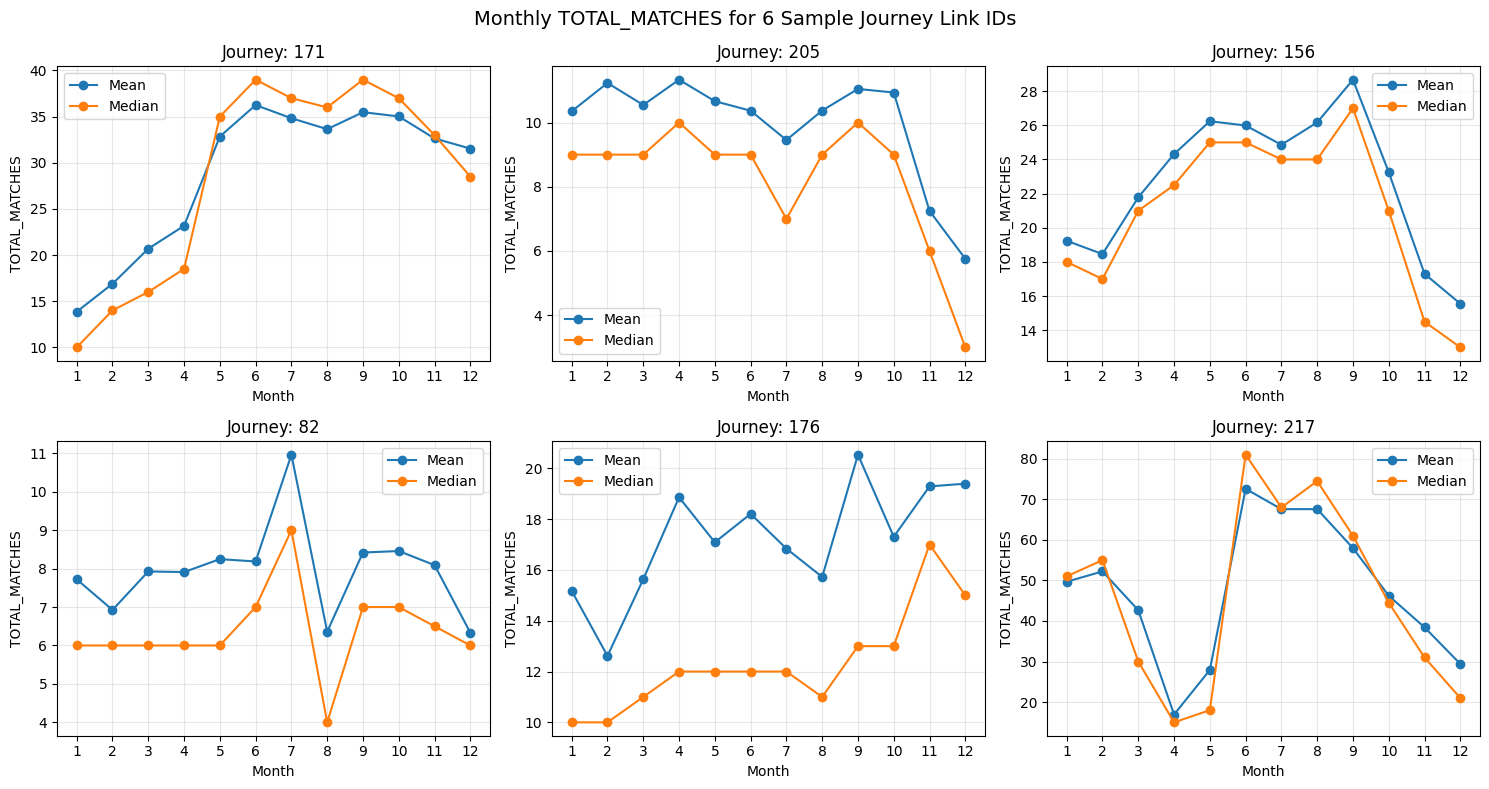

In [16]:


sample_ids = random.sample(list(complete_links['JOURNEY_LINK_ID']), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, journey_id in enumerate(sample_ids):
    group = monthly_agg[monthly_agg['JOURNEY_LINK_ID'] == journey_id]
    axes[i].plot(group['MONTH'], group['mean'], marker='o', label='Mean')
    axes[i].plot(group['MONTH'], group['median'], marker='o', label='Median')
    axes[i].set_title(f'Journey: {journey_id}')
    axes[i].set_xlabel('Month')
    axes[i].set_ylabel('TOTAL_MATCHES')
    axes[i].set_xticks(range(1, 13))
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Monthly TOTAL_MATCHES for 6 Sample Journey Link IDs', fontsize=14)
plt.tight_layout()
plt.show()

In [17]:
# Define seasonal bins by month
bins = [1, 4, 7, 10, 13]
labels = ['Spring', 'Summer', 'Autumn', 'Winter']

counts_df['SEASON'] = pd.cut(counts_df['MONTH'], bins=bins, labels=labels, right=False)

# Find which seasons each journey link ID has
bins_per_link = counts_df.groupby('JOURNEY_LINK_ID')['SEASON'].apply(set).reset_index(name='seasons')

# Identify routes missing at least one season
all_bins = set(labels)
incomplete_links = bins_per_link[bins_per_link['seasons'].apply(lambda x: not all_bins.issubset(x))]

print(f"Total journey link IDs: {bins_per_link['JOURNEY_LINK_ID'].nunique()}")
print(f"Journey link IDs missing at least one season: {len(incomplete_links)}")
print()
print(incomplete_links[['JOURNEY_LINK_ID', 'seasons']])

incomplete_link_ids = incomplete_links['JOURNEY_LINK_ID']

counts_df = counts_df[~counts_df['JOURNEY_LINK_ID'].isin(incomplete_link_ids)]

print(f"Removed {len(incomplete_link_ids)} journey link IDs with incomplete seasonal coverage")
print(f"Remaining rows: {len(counts_df)}")
print(f"Remaining journey link IDs: {counts_df['JOURNEY_LINK_ID'].nunique()}")

Total journey link IDs: 118
Journey link IDs missing at least one season: 18

     JOURNEY_LINK_ID                   seasons
5                 11  {Autumn, Spring, Summer}
22                50  {Spring, Winter, Summer}
26                54  {Autumn, Spring, Summer}
30                62  {Spring, Autumn, Summer}
31                63  {Autumn, Spring, Summer}
32                64  {Autumn, Spring, Summer}
33                65  {Spring, Autumn, Summer}
34                68  {Autumn, Spring, Summer}
35                69  {Spring, Autumn, Summer}
36                70  {Spring, Autumn, Summer}
43                77  {Spring, Autumn, Summer}
49                92  {Spring, Autumn, Summer}
70               150          {Autumn, Winter}
71               151          {Autumn, Winter}
83               167  {Autumn, Spring, Summer}
99               201  {Autumn, Spring, Summer}
108              211  {Spring, Autumn, Summer}
113              225  {Spring, Winter, Summer}
Removed 18 journey link IDs w

Journey link IDs with all 7 days: 98


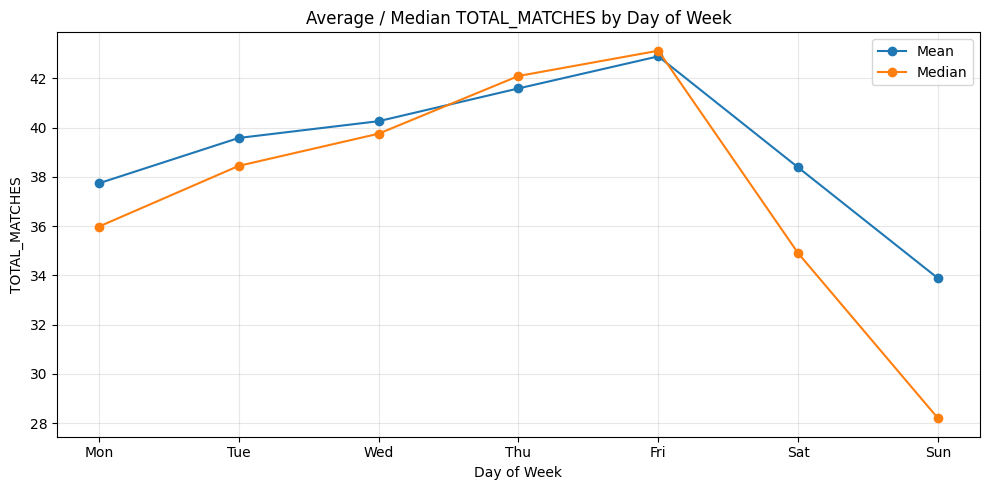

In [18]:
# day of week mean and median plot
counts_df['DAY_OF_WEEK'] = counts_df['DATE'].apply(lambda x: x.weekday())

days_per_link = counts_df.groupby('JOURNEY_LINK_ID')['DAY_OF_WEEK'].apply(set).reset_index(name='days')

all_days = set(range(7))
complete_links = days_per_link[days_per_link['days'].apply(lambda x: all_days.issubset(x))]

print(f"Journey link IDs with all 7 days: {len(complete_links)}")

# Filter to only journey link IDs with all 7 days
counts_df_complete = counts_df[counts_df['JOURNEY_LINK_ID'].isin(complete_links['JOURNEY_LINK_ID'])]

# Aggregate average and median TOTAL_MATCHES per journey link ID and day of week
daily_agg = counts_df_complete.groupby(['JOURNEY_LINK_ID', 'DAY_OF_WEEK'])['TOTAL_MATCHES'].agg(['mean', 'median']).reset_index()

# Average across all journey link IDs per day
daily_summary = daily_agg.groupby('DAY_OF_WEEK')[['mean', 'median']].mean().reset_index()

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(daily_summary['DAY_OF_WEEK'], daily_summary['mean'], label='Mean', marker='o')
ax.plot(daily_summary['DAY_OF_WEEK'], daily_summary['median'], label='Median', marker='o')
ax.set_xlabel('Day of Week')
ax.set_ylabel('TOTAL_MATCHES')
ax.set_title('Average / Median TOTAL_MATCHES by Day of Week')
ax.set_xticks(range(7))
ax.set_xticklabels(day_labels)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

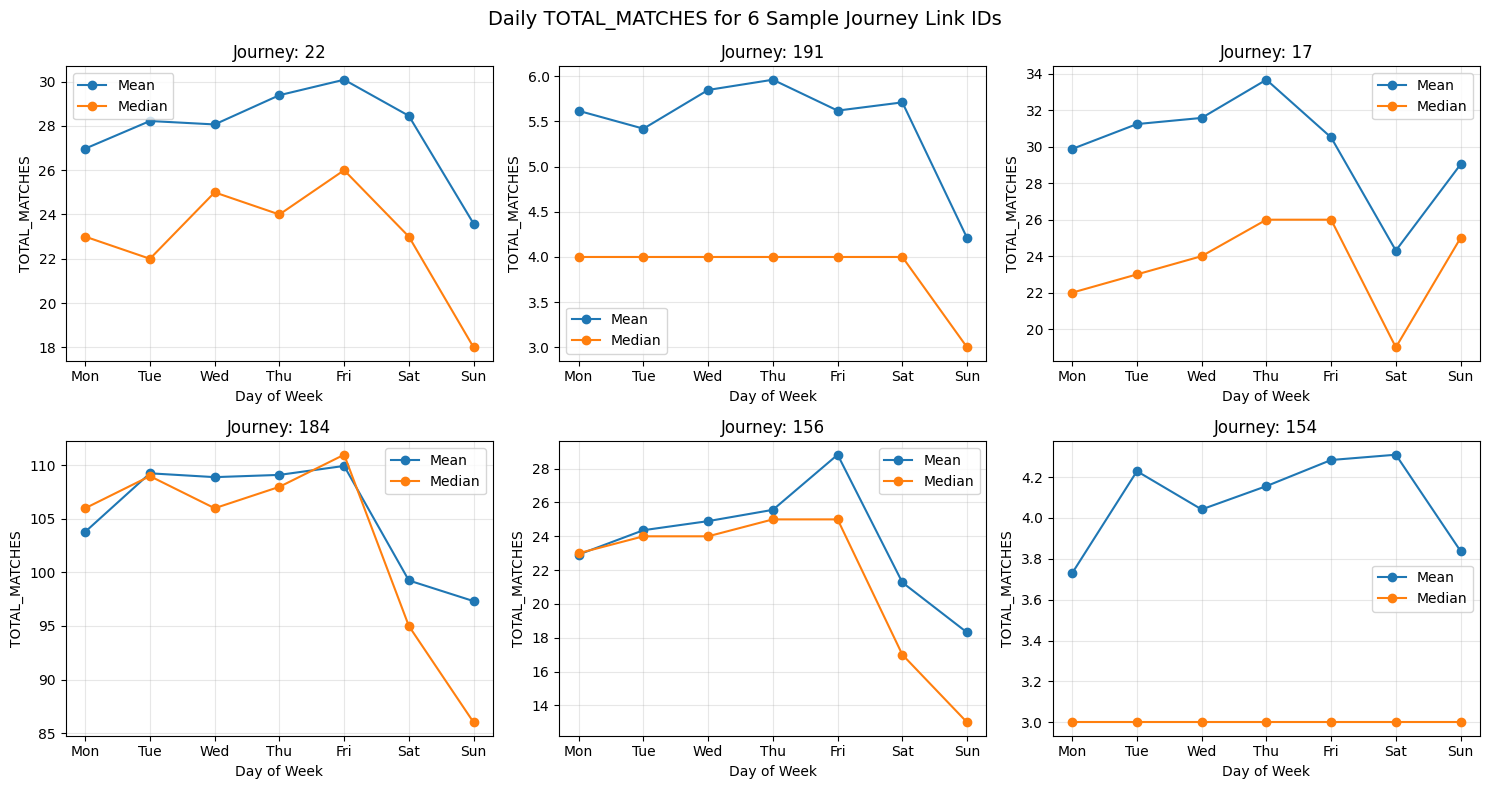

In [19]:
sample_ids = random.sample(list(complete_links['JOURNEY_LINK_ID']), 6)

day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, journey_id in enumerate(sample_ids):
    group = daily_agg[daily_agg['JOURNEY_LINK_ID'] == journey_id]
    axes[i].plot(group['DAY_OF_WEEK'], group['mean'], marker='o', label='Mean')
    axes[i].plot(group['DAY_OF_WEEK'], group['median'], marker='o', label='Median')
    axes[i].set_title(f'Journey: {journey_id}')
    axes[i].set_xlabel('Day of Week')
    axes[i].set_ylabel('TOTAL_MATCHES')
    axes[i].set_xticks(range(7))
    axes[i].set_xticklabels(day_labels)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Daily TOTAL_MATCHES for 6 Sample Journey Link IDs', fontsize=14)
plt.tight_layout()
plt.show()

In [20]:
# remove any journeys without the full 7 days
incomplete_links = days_per_link[days_per_link['days'].apply(lambda x: not all_days.issubset(x))]
incomplete_link_ids = incomplete_links['JOURNEY_LINK_ID']

counts_df = counts_df[~counts_df['JOURNEY_LINK_ID'].isin(incomplete_link_ids)]

print(f"Removed {len(incomplete_link_ids)} journey link IDs with incomplete day of week coverage")
print(f"Remaining rows: {len(counts_df)}")
print(f"Remaining journey link IDs: {counts_df['JOURNEY_LINK_ID'].nunique()}")

Removed 2 journey link IDs with incomplete day of week coverage
Remaining rows: 352957
Remaining journey link IDs: 98


In [21]:


# Load datasets
journey_links = gpd.read_file('/content/drive/MyDrive/journey_Links_300m.geojson')
air_quality = pd.read_csv('/content/drive/MyDrive/continuous_air_quality_2324.csv')

# Deduplicate to one row per sensor
sensors = air_quality.drop_duplicates(subset='SITE_ID')[['SITE_ID', 'EASTING', 'NORTHING']]
print(f"Unique sensors: {len(sensors)}")

# Convert to GeoDataFrame using Easting/Northing (already BNG)
sensors_gdf = gpd.GeoDataFrame(
    sensors,
    geometry=gpd.points_from_xy(sensors['EASTING'], sensors['NORTHING']),
    crs='EPSG:27700'
)
# Fix type mismatch - convert geojson JOURNEY_LINK_ID to int
journey_links['JOURNEY_LINK_ID'] = journey_links['JOURNEY_LINK_ID'].astype(int)

# Now filter
journey_links = journey_links[journey_links['JOURNEY_LINK_ID'].isin(counts_df['JOURNEY_LINK_ID'])]
journey_links = journey_links.to_crs(epsg=27700)

print(f"Journey links after filtering: {len(journey_links)}")

# Buffer sensors by 300m
sensors_gdf['geometry_buffer'] = sensors_gdf.geometry.buffer(300)
sensors_buffered = sensors_gdf.set_geometry('geometry_buffer')

# Spatial join
joined = gpd.sjoin(journey_links, sensors_buffered[['SITE_ID', 'geometry_buffer']], how='left', predicate='intersects')

# Count journeys per sensor
journeys_per_sensor = joined.groupby('SITE_ID')['JOURNEY_LINK_ID'].nunique().reset_index()
journeys_per_sensor.columns = ['SITE_ID', 'JOURNEY_COUNT']

print("\nJourneys mapped per sensor:")
print(journeys_per_sensor)


Unique sensors: 8
Journey links after filtering: 98

Journeys mapped per sensor:
   SITE_ID  JOURNEY_COUNT
0      203             10
1      215             11
2      270              9
3      452              8
4      463              7
5      500             50
6      501             22
7      672             16


/tmp/ipykernel_2163/4087772722.py:3: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  air_quality = pd.read_csv('/content/drive/MyDrive/continuous_air_quality_2324.csv')


In [35]:
# cut each route up into segments and find the distance of the segment
# find the distance between each segment and the nearest sensor / their corresponding sensor
from shapely.geometry import LineString
import numpy as np

def segmentize_by_angle(line, angle_threshold=8):
    """Split a linestring at bends exceeding angle_threshold degrees"""
    coords = list(line.coords)

    if len(coords) < 3:
        return [line]

    segments = []
    current_segment = [coords[0]]

    for i in range(1, len(coords) - 1):
        current_segment.append(coords[i])

        # Calculate angle between consecutive vectors
        v1 = np.array(coords[i]) - np.array(coords[i-1])
        v2 = np.array(coords[i+1]) - np.array(coords[i])

        # Calculate angle between vectors
        cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10)
        cos_angle = np.clip(cos_angle, -1, 1)
        angle = np.degrees(np.arccos(cos_angle))

        # Split at bend
        if angle > angle_threshold:
            segments.append(LineString(current_segment))
            current_segment = [coords[i]]

    # Add final segment
    current_segment.append(coords[-1])
    if len(current_segment) >= 2:
        segments.append(LineString(current_segment))

    return segments

# Segmentize all journey links by angle
rows = []
for _, row in journey_links.iterrows():
    segments = segmentize_by_angle(row.geometry, angle_threshold=8)
    for j, seg in enumerate(segments):
        rows.append({
            'JOURNEY_LINK_ID': row['JOURNEY_LINK_ID'],
            'SEGMENT_ID': j,
            'SEGMENT_LENGTH': seg.length,
            'geometry': seg
        })

segments_gdf = gpd.GeoDataFrame(rows, crs='EPSG:27700')
print(f"Total segments: {len(segments_gdf)}")
print(f"Avg segments per route: {len(segments_gdf) / journey_links['JOURNEY_LINK_ID'].nunique():.1f}")

# Calculate shortest distance from each segment to nearest sensor
def nearest_sensor_distance(segment_geom, sensors_gdf):
    distances = sensors_gdf.geometry.distance(segment_geom)
    min_dist = distances.min()
    nearest_site = sensors_gdf.loc[distances.idxmin(), 'SITE_ID']
    return min_dist, nearest_site

segments_gdf[['DIST_TO_SENSOR', 'NEAREST_SITE_ID']] = segments_gdf['geometry'].apply(
    lambda geom: pd.Series(nearest_sensor_distance(geom, sensors_gdf))
)

# Remove segments not within 300m of any sensor
segments_gdf = segments_gdf[segments_gdf['DIST_TO_SENSOR'] <= 300]

print(f"Segments within 300m of a sensor: {len(segments_gdf)}")
print(f"Avg segment length: {segments_gdf['SEGMENT_LENGTH'].mean():.1f}m")
print(segments_gdf.head())



Total segments: 2159
Avg segments per route: 22.0
Segments within 300m of a sensor: 653
Avg segment length: 115.1m
    JOURNEY_LINK_ID  SEGMENT_ID  SEGMENT_LENGTH  \
19                9          19      548.333480   
20                9          20       49.433423   
21                9          21      339.144927   
24               21           0       28.547775   
25               21           1       61.279406   

                                             geometry  DIST_TO_SENSOR  \
19  LINESTRING (358377.372 170872.398, 358347.979 ...        9.996996   
20  LINESTRING (357949.818 170531.128, 357902.428 ...      105.287485   
21  LINESTRING (357902.428 170517.063, 357871.814 ...      153.939012   
24  LINESTRING (359611.812 173657.228, 359638.95 1...      290.461636   
25  LINESTRING (359638.95 173666.087, 359691.311 1...      298.797692   

    NEAREST_SITE_ID  
19            215.0  
20            215.0  
21            215.0  
24            500.0  
25            452.0  


In [37]:
import math

def get_direction(segment_geom, sensor_geom):
    """Calculate cardinal direction from segment midpoint to sensor"""
    midpoint = segment_geom.interpolate(0.5, normalized=True)

    dx = sensor_geom.x - midpoint.x
    dy = sensor_geom.y - midpoint.y

    angle = math.degrees(math.atan2(dy, dx))
    bearing = (90 - angle) % 360

    if bearing < 22.5 or bearing >= 337.5:
        return 'N'
    elif bearing < 67.5:
        return 'NE'
    elif bearing < 112.5:
        return 'E'
    elif bearing < 157.5:
        return 'SE'
    elif bearing < 202.5:
        return 'S'
    elif bearing < 247.5:
        return 'SW'
    elif bearing < 292.5:
        return 'W'
    else:
        return 'NW'

# Build sensor geometry lookup dict to avoid index alignment issues
segments_gdf['NEAREST_SITE_ID'] = segments_gdf['NEAREST_SITE_ID'].astype(int)
sensor_geom_lookup = sensors_gdf.set_index('SITE_ID')['geometry'].to_dict()

# Calculate direction directly on segments_gdf
segments_gdf['SENSOR_DIRECTION'] = segments_gdf.apply(
    lambda row: get_direction(row['geometry'], sensor_geom_lookup[row['NEAREST_SITE_ID']]), axis=1
)

print(segments_gdf[['JOURNEY_LINK_ID', 'SEGMENT_ID', 'NEAREST_SITE_ID', 'DIST_TO_SENSOR', 'SENSOR_DIRECTION']].head(10))
print("\nDirection distribution:")
print(segments_gdf['SENSOR_DIRECTION'].value_counts())
print(f"\nTotal directions assigned: {segments_gdf['SENSOR_DIRECTION'].value_counts().sum()}")

    JOURNEY_LINK_ID  SEGMENT_ID  NEAREST_SITE_ID  DIST_TO_SENSOR  \
19                9          19              215        9.996996   
20                9          20              215      105.287485   
21                9          21              215      153.939012   
24               21           0              500      290.461636   
25               21           1              452      298.797692   
50               21          26              463        6.842689   
68               29          13              500      289.066917   
69               29          14              500      102.879593   
70               29          15              500       58.410939   
71               29          16              500       21.043866   

   SENSOR_DIRECTION  
19               SW  
20               NE  
21                E  
24                S  
25               NW  
50                W  
68                N  
69                N  
70               NE  
71               SE  

Directio

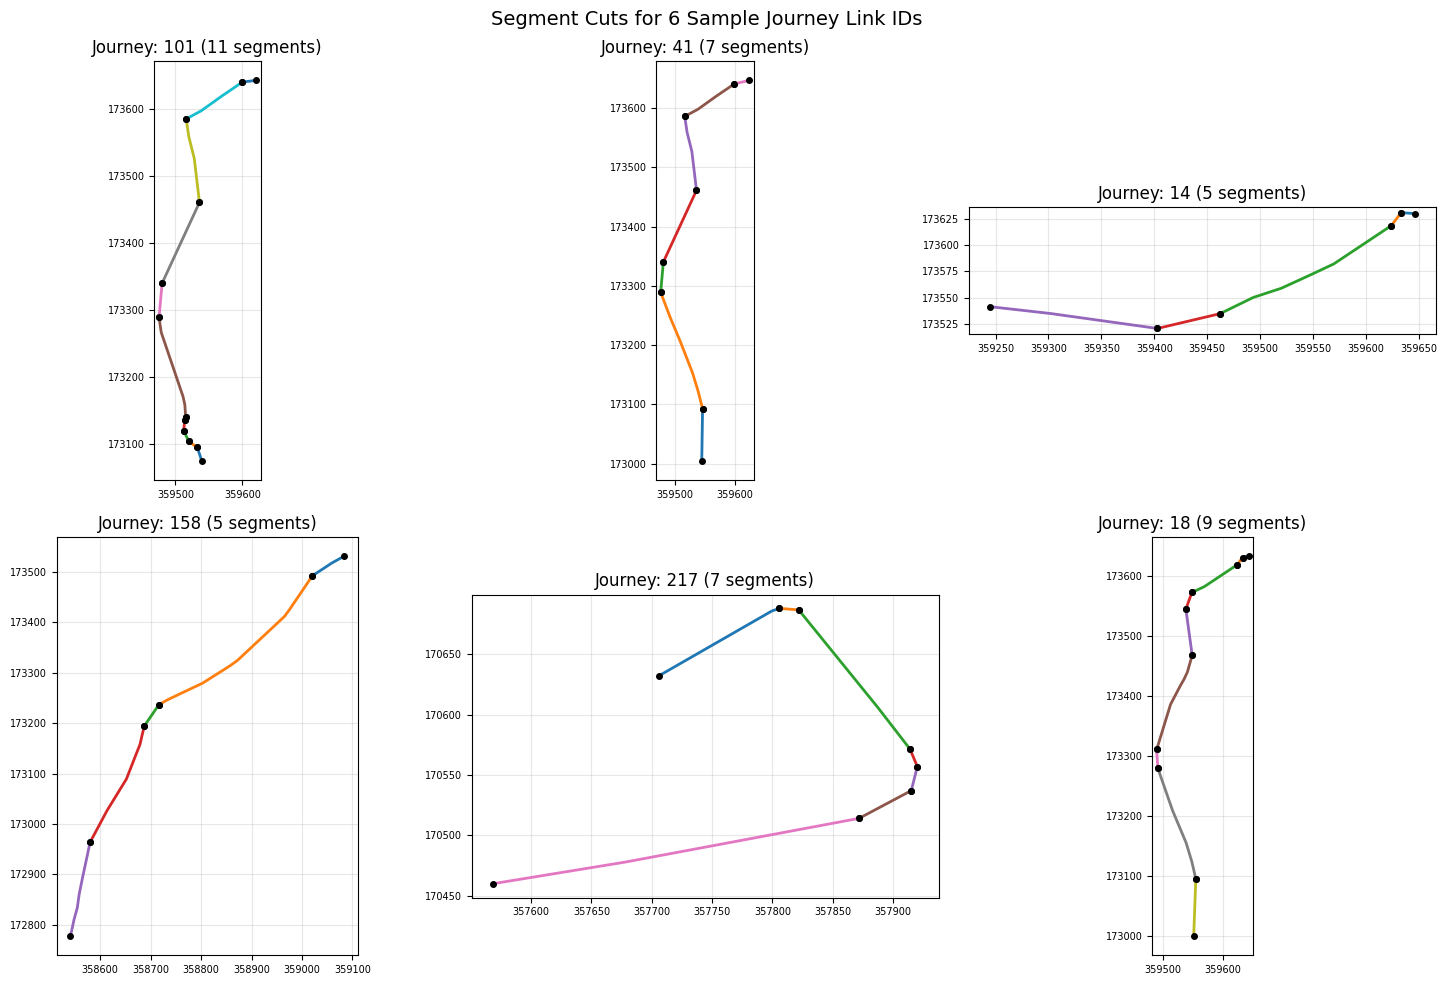

In [ ]:
import matplotlib.pyplot as plt
import random

sample_ids = random.sample(list(segments_gdf['JOURNEY_LINK_ID'].unique()), 6)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

colors = plt.cm.tab10.colors

for i, journey_id in enumerate(sample_ids):
    segs = segments_gdf[segments_gdf['JOURNEY_LINK_ID'] == journey_id]

    for j, (_, seg) in enumerate(segs.iterrows()):
        x, y = seg.geometry.xy
        axes[i].plot(x, y, color=colors[j % len(colors)], linewidth=2)
        # Mark the split points
        axes[i].plot(x[0], y[0], 'ko', markersize=4)
        axes[i].plot(x[-1], y[-1], 'ko', markersize=4)

    axes[i].set_title(f'Journey: {journey_id} ({len(segs)} segments)')
    axes[i].set_aspect('equal')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Segment Cuts for 6 Sample Journey Link IDs', fontsize=14)
plt.tight_layout()
plt.show()

In [39]:
# find the proportion of how much each segment contributes in terms of length for their relevant sensor
# Total length of all segments per site
site_total_length = segments_gdf.groupby('NEAREST_SITE_ID')['SEGMENT_LENGTH'].sum().reset_index()
site_total_length.columns = ['NEAREST_SITE_ID', 'SITE_TOTAL_LENGTH']

# Merge back and calculate proportion
segments_gdf = segments_gdf.merge(site_total_length, on='NEAREST_SITE_ID', how='left')
segments_gdf['LENGTH_PROPORTION'] = segments_gdf['SEGMENT_LENGTH'] / segments_gdf['SITE_TOTAL_LENGTH']
segments_gdf = gpd.GeoDataFrame(segments_gdf, geometry='geometry', crs='EPSG:27700')

print(f"\nType: {type(segments_gdf)}")
print(f"CRS: {segments_gdf.crs}")
print(f"Total segments: {len(segments_gdf)}")

print(segments_gdf[['JOURNEY_LINK_ID', 'SEGMENT_ID', 'NEAREST_SITE_ID', 'SEGMENT_LENGTH', 'SITE_TOTAL_LENGTH', 'LENGTH_PROPORTION']].head(10))

# Sanity check - proportions should sum to 1 per site
print("\nProportion sum per site (should all be 1.0):")
print(segments_gdf.groupby('NEAREST_SITE_ID')['LENGTH_PROPORTION'].sum())


Type: <class 'geopandas.geodataframe.GeoDataFrame'>
CRS: EPSG:27700
Total segments: 653
   JOURNEY_LINK_ID  SEGMENT_ID  NEAREST_SITE_ID  SEGMENT_LENGTH  \
0                9          19              215      548.333480   
1                9          20              215       49.433423   
2                9          21              215      339.144927   
3               21           0              500       28.547775   
4               21           1              452       61.279406   
5               21          26              463      797.294867   
6               29          13              500       87.861810   
7               29          14              500      208.912571   
8               29          15              500       51.327843   
9               29          16              500      133.069125   

   SITE_TOTAL_LENGTH  LENGTH_PROPORTION  
0       10217.668047           0.053665  
1       10217.668047           0.004838  
2       10217.668047           0.033192  
3    

In [40]:
segments_gdf.head()

,JOURNEY_LINK_ID,SEGMENT_ID,SEGMENT_LENGTH,geometry,DIST_TO_SENSOR,NEAREST_SITE_ID,SENSOR_DIRECTION,SITE_TOTAL_LENGTH,LENGTH_PROPORTION
0,9,19,548.333480,"LINESTRING (358377.372 170872.398, 358347.979 ...",9.996996,215,SW,10217.668047,0.053665
1,9,20,49.433423,"LINESTRING (357949.818 170531.128, 357902.428 ...",105.287485,215,NE,10217.668047,0.004838
2,9,21,339.144927,"LINESTRING (357902.428 170517.063, 357871.814 ...",153.939012,215,E,10217.668047,0.033192
3,21,0,28.547775,"LINESTRING (359611.812 173657.228, 359638.95 1...",290.461636,500,S,28677.983497,0.000995
4,21,1,61.279406,"LINESTRING (359638.95 173666.087, 359691.311 1...",298.797692,452,NW,1300.884940,0.047106


In [41]:
segments_gdf.to_file('/content/drive/MyDrive/segments.geojson', driver='GeoJSON')
print("Saved!")

Saved!


In [ ]:
# find the typcial journey count for a specific route (could be mean or median)
# put it in a new dataset (with journey link ID)
index_df = counts_df.groupby('JOURNEY_LINK_ID')['TOTAL_MATCHES'].agg(
    baseline_mean='mean',
    baseline_median='median',
    data_points='count'
).reset_index()

print(f"Index dataset shape: {index_df.shape}")
print(index_df.head(10))


Index dataset shape: (98, 4)
   JOURNEY_LINK_ID  baseline_mean  baseline_median  data_points
0                3       3.999187              3.0         1230
1                6       4.315417              3.0         2121
2                7       7.539585              6.0         3562
3                9      38.459289             35.0         6497
4               10      17.912295             14.0         3660
5               12       4.974506              3.0         1922
6               14     415.451470            398.0         6532
7               17      30.122702             23.0         4352
8               18      18.450097             16.0         4619
9               19      54.206274             53.0         4877


In [ ]:
# Calculate mean and median per journey link ID and time bin
timebin_agg = counts_df.groupby(['JOURNEY_LINK_ID', 'TIME_BIN'], observed=True)['TOTAL_MATCHES'].agg(['mean', 'median']).reset_index()
# Merge with baseline values
timebin_agg = timebin_agg.merge(index_df[['JOURNEY_LINK_ID', 'baseline_mean', 'baseline_median']], on='JOURNEY_LINK_ID')

# Calculate index (bin value / baseline)
timebin_agg['index_mean'] = timebin_agg['mean'] / timebin_agg['baseline_mean']
timebin_agg['index_median'] = timebin_agg['median'] / timebin_agg['baseline_median']

# Pivot so each time bin becomes its own columns in index_df
for bin_label in counts_df['TIME_BIN'].unique():
    bin_data = timebin_agg[timebin_agg['TIME_BIN'] == bin_label][['JOURNEY_LINK_ID', 'index_mean', 'index_median']]
    bin_data = bin_data.rename(columns={
        'index_mean': f'tod_index_mean_{bin_label}',
        'index_median': f'tod_index_median_{bin_label}'
    })
    index_df = index_df.merge(bin_data, on='JOURNEY_LINK_ID', how='left')

print(index_df.shape)
print(index_df.head())


(98, 12)
   JOURNEY_LINK_ID  baseline_mean  baseline_median  data_points  \
0                3       3.999187              3.0         1230   
1                6       4.315417              3.0         2121   
2                7       7.539585              6.0         3562   
3                9      38.459289             35.0         6497   
4               10      17.912295             14.0         3660   

   tod_index_mean_18-24  tod_index_median_18-24  tod_index_mean_06-12  \
0              1.019652                1.000000              0.948911   
1              1.107332                1.000000              0.860012   
2              1.122243                1.000000              1.015766   
3              0.993378                1.000000              0.899769   
4              0.870652                0.785714              1.406478   

   tod_index_median_06-12  tod_index_mean_00-06  tod_index_median_00-06  \
0                1.000000              1.074894                1.000000   

In [ ]:
# DAY OF WEEK INDEX
dow_agg = counts_df.groupby(['JOURNEY_LINK_ID', 'DAY_OF_WEEK'], observed=True)['TOTAL_MATCHES'].agg(['mean', 'median']).reset_index()

dow_agg = dow_agg.merge(index_df[['JOURNEY_LINK_ID', 'baseline_mean', 'baseline_median']], on='JOURNEY_LINK_ID')

dow_agg['index_mean'] = dow_agg['mean'] / dow_agg['baseline_mean']
dow_agg['index_median'] = dow_agg['median'] / dow_agg['baseline_median']

for day in sorted(counts_df['DAY_OF_WEEK'].unique()):
    day_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
    day_name = day_labels[day]
    day_data = dow_agg[dow_agg['DAY_OF_WEEK'] == day][['JOURNEY_LINK_ID', 'index_mean', 'index_median']]
    day_data = day_data.rename(columns={
        'index_mean': f'dow_index_mean_{day_name}',
        'index_median': f'dow_index_median_{day_name}'
    })
    index_df = index_df.merge(day_data, on='JOURNEY_LINK_ID', how='left')

# SEASON INDEX
season_agg = counts_df.groupby(['JOURNEY_LINK_ID', 'SEASON'], observed=True)['TOTAL_MATCHES'].agg(['mean', 'median']).reset_index()

season_agg = season_agg.merge(index_df[['JOURNEY_LINK_ID', 'baseline_mean', 'baseline_median']], on='JOURNEY_LINK_ID')

season_agg['index_mean'] = season_agg['mean'] / season_agg['baseline_mean']
season_agg['index_median'] = season_agg['median'] / season_agg['baseline_median']

for season in counts_df['SEASON'].cat.categories:
    season_data = season_agg[season_agg['SEASON'] == season][['JOURNEY_LINK_ID', 'index_mean', 'index_median']]
    season_data = season_data.rename(columns={
        'index_mean': f'season_index_mean_{season}',
        'index_median': f'season_index_median_{season}'
    })
    index_df = index_df.merge(season_data, on='JOURNEY_LINK_ID', how='left')



(98, 34)
['JOURNEY_LINK_ID', 'baseline_mean', 'baseline_median', 'data_points', 'tod_index_mean_18-24', 'tod_index_median_18-24', 'tod_index_mean_06-12', 'tod_index_median_06-12', 'tod_index_mean_00-06', 'tod_index_median_00-06', 'tod_index_mean_12-18', 'tod_index_median_12-18', 'dow_index_mean_Mon', 'dow_index_median_Mon', 'dow_index_mean_Tue', 'dow_index_median_Tue', 'dow_index_mean_Wed', 'dow_index_median_Wed', 'dow_index_mean_Thu', 'dow_index_median_Thu', 'dow_index_mean_Fri', 'dow_index_median_Fri', 'dow_index_mean_Sat', 'dow_index_median_Sat', 'dow_index_mean_Sun', 'dow_index_median_Sun', 'season_index_mean_Spring', 'season_index_median_Spring', 'season_index_mean_Summer', 'season_index_median_Summer', 'season_index_mean_Autumn', 'season_index_median_Autumn', 'season_index_mean_Winter', 'season_index_median_Winter']


In [ ]:
# SPEED BASELINE
speed_baseline = counts_df.groupby('JOURNEY_LINK_ID')['SPEED'].agg(
    speed_baseline_mean='mean',
    speed_baseline_median='median'
).reset_index()

index_df = index_df.merge(speed_baseline, on='JOURNEY_LINK_ID', how='left')

# SPEED TOD INDEX
speed_timebin_agg = counts_df.groupby(['JOURNEY_LINK_ID', 'TIME_BIN'], observed=True)['SPEED'].agg(['mean', 'median']).reset_index()
speed_timebin_agg = speed_timebin_agg.merge(index_df[['JOURNEY_LINK_ID', 'speed_baseline_mean', 'speed_baseline_median']], on='JOURNEY_LINK_ID')
speed_timebin_agg['speed_tod_index_mean'] = speed_timebin_agg['mean'] / speed_timebin_agg['speed_baseline_mean']
speed_timebin_agg['speed_tod_index_median'] = speed_timebin_agg['median'] / speed_timebin_agg['speed_baseline_median']

for bin_label in counts_df['TIME_BIN'].cat.categories:
    bin_data = speed_timebin_agg[speed_timebin_agg['TIME_BIN'] == bin_label][['JOURNEY_LINK_ID', 'speed_tod_index_mean', 'speed_tod_index_median']]
    bin_data = bin_data.rename(columns={'speed_tod_index_mean': f'speed_tod_index_mean_{bin_label}', 'speed_tod_index_median': f'speed_tod_index_median_{bin_label}'})
    index_df = index_df.merge(bin_data, on='JOURNEY_LINK_ID', how='left')

# SPEED DOW INDEX
speed_dow_agg = counts_df.groupby(['JOURNEY_LINK_ID', 'DAY_OF_WEEK'], observed=True)['SPEED'].agg(['mean', 'median']).reset_index()
speed_dow_agg = speed_dow_agg.merge(index_df[['JOURNEY_LINK_ID', 'speed_baseline_mean', 'speed_baseline_median']], on='JOURNEY_LINK_ID')
speed_dow_agg['speed_dow_index_mean'] = speed_dow_agg['mean'] / speed_dow_agg['speed_baseline_mean']
speed_dow_agg['speed_dow_index_median'] = speed_dow_agg['median'] / speed_dow_agg['speed_baseline_median']

day_labels = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
for day in sorted(counts_df['DAY_OF_WEEK'].unique()):
    day_name = day_labels[day]
    day_data = speed_dow_agg[speed_dow_agg['DAY_OF_WEEK'] == day][['JOURNEY_LINK_ID', 'speed_dow_index_mean', 'speed_dow_index_median']]
    day_data = day_data.rename(columns={'speed_dow_index_mean': f'speed_dow_index_mean_{day_name}', 'speed_dow_index_median': f'speed_dow_index_median_{day_name}'})
    index_df = index_df.merge(day_data, on='JOURNEY_LINK_ID', how='left')

# SPEED SEASON INDEX
speed_season_agg = counts_df.groupby(['JOURNEY_LINK_ID', 'SEASON'], observed=True)['SPEED'].agg(['mean', 'median']).reset_index()
speed_season_agg = speed_season_agg.merge(index_df[['JOURNEY_LINK_ID', 'speed_baseline_mean', 'speed_baseline_median']], on='JOURNEY_LINK_ID')
speed_season_agg['speed_season_index_mean'] = speed_season_agg['mean'] / speed_season_agg['speed_baseline_mean']
speed_season_agg['speed_season_index_median'] = speed_season_agg['median'] / speed_season_agg['speed_baseline_median']

for season in counts_df['SEASON'].cat.categories:
    season_data = speed_season_agg[speed_season_agg['SEASON'] == season][['JOURNEY_LINK_ID', 'speed_season_index_mean', 'speed_season_index_median']]
    season_data = season_data.rename(columns={'speed_season_index_mean': f'speed_season_index_mean_{season}', 'speed_season_index_median': f'speed_season_index_median_{season}'})
    index_df = index_df.merge(season_data, on='JOURNEY_LINK_ID', how='left')

print(f"index_df shape: {index_df.shape}")
print([c for c in index_df.columns if 'speed' in c])

index_df shape: (98, 66)
['speed_baseline_mean', 'speed_baseline_median', 'speed_tod_index_mean_00-06', 'speed_tod_index_median_00-06', 'speed_tod_index_mean_06-12', 'speed_tod_index_median_06-12', 'speed_tod_index_mean_12-18', 'speed_tod_index_median_12-18', 'speed_tod_index_mean_18-24', 'speed_tod_index_median_18-24', 'speed_dow_index_mean_Mon', 'speed_dow_index_median_Mon', 'speed_dow_index_mean_Tue', 'speed_dow_index_median_Tue', 'speed_dow_index_mean_Wed', 'speed_dow_index_median_Wed', 'speed_dow_index_mean_Thu', 'speed_dow_index_median_Thu', 'speed_dow_index_mean_Fri', 'speed_dow_index_median_Fri', 'speed_dow_index_mean_Sat', 'speed_dow_index_median_Sat', 'speed_dow_index_mean_Sun', 'speed_dow_index_median_Sun', 'speed_season_index_mean_Spring', 'speed_season_index_median_Spring', 'speed_season_index_mean_Summer', 'speed_season_index_median_Summer', 'speed_season_index_mean_Autumn', 'speed_season_index_median_Autumn', 'speed_season_index_mean_Winter', 'speed_season_index_median_W

In [ ]:
import pandas as pd
import numpy as np

# Generate all dates in 2023
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')
hours = range(24)
journey_ids = counts_df['JOURNEY_LINK_ID'].unique()

# Create a row for every journey link, date and hour
rows = []
for date in dates:
    for hour in hours:
        for journey_id in journey_ids:
            rows.append({
                'JOURNEY_LINK_ID': journey_id,
                'DATE': date.date(),
                'HOUR': hour,
                'TIME': pd.Timestamp(f'{date.date()} {hour:02d}:00:00').time()
            })

temporal_df = pd.DataFrame(rows)
print(f"Total rows: {len(temporal_df)}")

# Add time features
temporal_df['DAY_OF_WEEK'] = pd.to_datetime(temporal_df['DATE']).dt.weekday
temporal_df['MONTH'] = pd.to_datetime(temporal_df['DATE']).dt.month

# Add TIME_BIN
bins = [0, 6, 12, 18, 24]
labels = ['00-06', '06-12', '12-18', '18-24']
temporal_df['TIME_BIN'] = pd.cut(temporal_df['HOUR'], bins=bins, labels=labels, right=False)

# Add SEASON
season_bins = [1, 4, 7, 10, 13]
season_labels = ['Spring', 'Summer', 'Autumn', 'Winter']
temporal_df['SEASON'] = pd.cut(temporal_df['MONTH'], bins=season_bins, labels=season_labels, right=False)

# Merge baseline values from index_df
temporal_df = temporal_df.merge(
    index_df[['JOURNEY_LINK_ID', 'baseline_mean', 'baseline_median', 'speed_baseline_mean', 'speed_baseline_median']],
    on='JOURNEY_LINK_ID', how='left'
)

# Setup lookup
index_lookup = index_df.set_index('JOURNEY_LINK_ID')
day_labels_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

# ── TOTAL MATCHES INDICES ──────────────────────────────────────────
temporal_df['tod_index_mean'] = temporal_df.apply(lambda row: index_lookup.loc[row['JOURNEY_LINK_ID'], f'tod_index_mean_{row["TIME_BIN"]}'], axis=1)
temporal_df['dow_index_mean'] = temporal_df.apply(lambda row: index_lookup.loc[row['JOURNEY_LINK_ID'], f'dow_index_mean_{day_labels_map[row["DAY_OF_WEEK"]]}'], axis=1)
temporal_df['season_index_mean'] = temporal_df.apply(lambda row: index_lookup.loc[row['JOURNEY_LINK_ID'], f'season_index_mean_{row["SEASON"]}'], axis=1)

temporal_df['tod_index_median'] = temporal_df.apply(lambda row: index_lookup.loc[row['JOURNEY_LINK_ID'], f'tod_index_median_{row["TIME_BIN"]}'], axis=1)
temporal_df['dow_index_median'] = temporal_df.apply(lambda row: index_lookup.loc[row['JOURNEY_LINK_ID'], f'dow_index_median_{day_labels_map[row["DAY_OF_WEEK"]]}'], axis=1)
temporal_df['season_index_median'] = temporal_df.apply(lambda row: index_lookup.loc[row['JOURNEY_LINK_ID'], f'season_index_median_{row["SEASON"]}'], axis=1)

temporal_df['TIME_INDEX_MEAN'] = temporal_df['tod_index_mean'] * temporal_df['dow_index_mean'] * temporal_df['season_index_mean']
temporal_df['TIME_INDEX_MEDIAN'] = temporal_df['tod_index_median'] * temporal_df['dow_index_median'] * temporal_df['season_index_median']

temporal_df['ESTIMATED_MATCHES_MEAN'] = temporal_df['baseline_mean'] * temporal_df['TIME_INDEX_MEAN']
temporal_df['ESTIMATED_MATCHES_MEDIAN'] = temporal_df['baseline_median'] * temporal_df['TIME_INDEX_MEDIAN']

# ── SPEED INDICES ──────────────────────────────────────────────────
temporal_df['speed_tod_index_mean'] = temporal_df.apply(lambda row: index_lookup.loc[row['JOURNEY_LINK_ID'], f'speed_tod_index_mean_{row["TIME_BIN"]}'], axis=1)
temporal_df['speed_dow_index_mean'] = temporal_df.apply(lambda row: index_lookup.loc[row['JOURNEY_LINK_ID'], f'speed_dow_index_mean_{day_labels_map[row["DAY_OF_WEEK"]]}'], axis=1)
temporal_df['speed_season_index_mean'] = temporal_df.apply(lambda row: index_lookup.loc[row['JOURNEY_LINK_ID'], f'speed_season_index_mean_{row["SEASON"]}'], axis=1)

temporal_df['speed_tod_index_median'] = temporal_df.apply(lambda row: index_lookup.loc[row['JOURNEY_LINK_ID'], f'speed_tod_index_median_{row["TIME_BIN"]}'], axis=1)
temporal_df['speed_dow_index_median'] = temporal_df.apply(lambda row: index_lookup.loc[row['JOURNEY_LINK_ID'], f'speed_dow_index_median_{day_labels_map[row["DAY_OF_WEEK"]]}'], axis=1)
temporal_df['speed_season_index_median'] = temporal_df.apply(lambda row: index_lookup.loc[row['JOURNEY_LINK_ID'], f'speed_season_index_median_{row["SEASON"]}'], axis=1)

temporal_df['SPEED_TIME_INDEX_MEAN'] = temporal_df['speed_tod_index_mean'] * temporal_df['speed_dow_index_mean'] * temporal_df['speed_season_index_mean']
temporal_df['SPEED_TIME_INDEX_MEDIAN'] = temporal_df['speed_tod_index_median'] * temporal_df['speed_dow_index_median'] * temporal_df['speed_season_index_median']

temporal_df['ESTIMATED_SPEED_MEAN'] = temporal_df['speed_baseline_mean'] * temporal_df['SPEED_TIME_INDEX_MEAN']
temporal_df['ESTIMATED_SPEED_MEDIAN'] = temporal_df['speed_baseline_median'] * temporal_df['SPEED_TIME_INDEX_MEDIAN']

print(f"Shape: {temporal_df.shape}")
print(temporal_df[[
    'JOURNEY_LINK_ID', 'DATE', 'TIME', 'TIME_BIN', 'SEASON',
    'ESTIMATED_MATCHES_MEAN', 'ESTIMATED_MATCHES_MEDIAN',
    'ESTIMATED_SPEED_MEAN', 'ESTIMATED_SPEED_MEDIAN'
]].head(10))

Total rows: 858480
Shape: (858480, 32)
   JOURNEY_LINK_ID        DATE      TIME TIME_BIN  SEASON  \
0               72  2023-01-01  00:00:00    00-06  Spring   
1               74  2023-01-01  00:00:00    00-06  Spring   
2              184  2023-01-01  00:00:00    00-06  Spring   
3               60  2023-01-01  00:00:00    00-06  Spring   
4              148  2023-01-01  00:00:00    00-06  Spring   
5               51  2023-01-01  00:00:00    00-06  Spring   
6                9  2023-01-01  00:00:00    00-06  Spring   
7              136  2023-01-01  00:00:00    00-06  Spring   
8               41  2023-01-01  00:00:00    00-06  Spring   
9              105  2023-01-01  00:00:00    00-06  Spring   

   ESTIMATED_MATCHES_MEAN  ESTIMATED_MATCHES_MEDIAN  ESTIMATED_SPEED_MEAN  \
0                6.585141                  3.832559             14.457113   
1               23.329860                 15.377229             15.527606   
2               13.406506                  7.124260       

In [ ]:
temporal_df.to_csv('/content/drive/MyDrive/traffic_density.csv', index=False)
print("Saved!")

Saved!


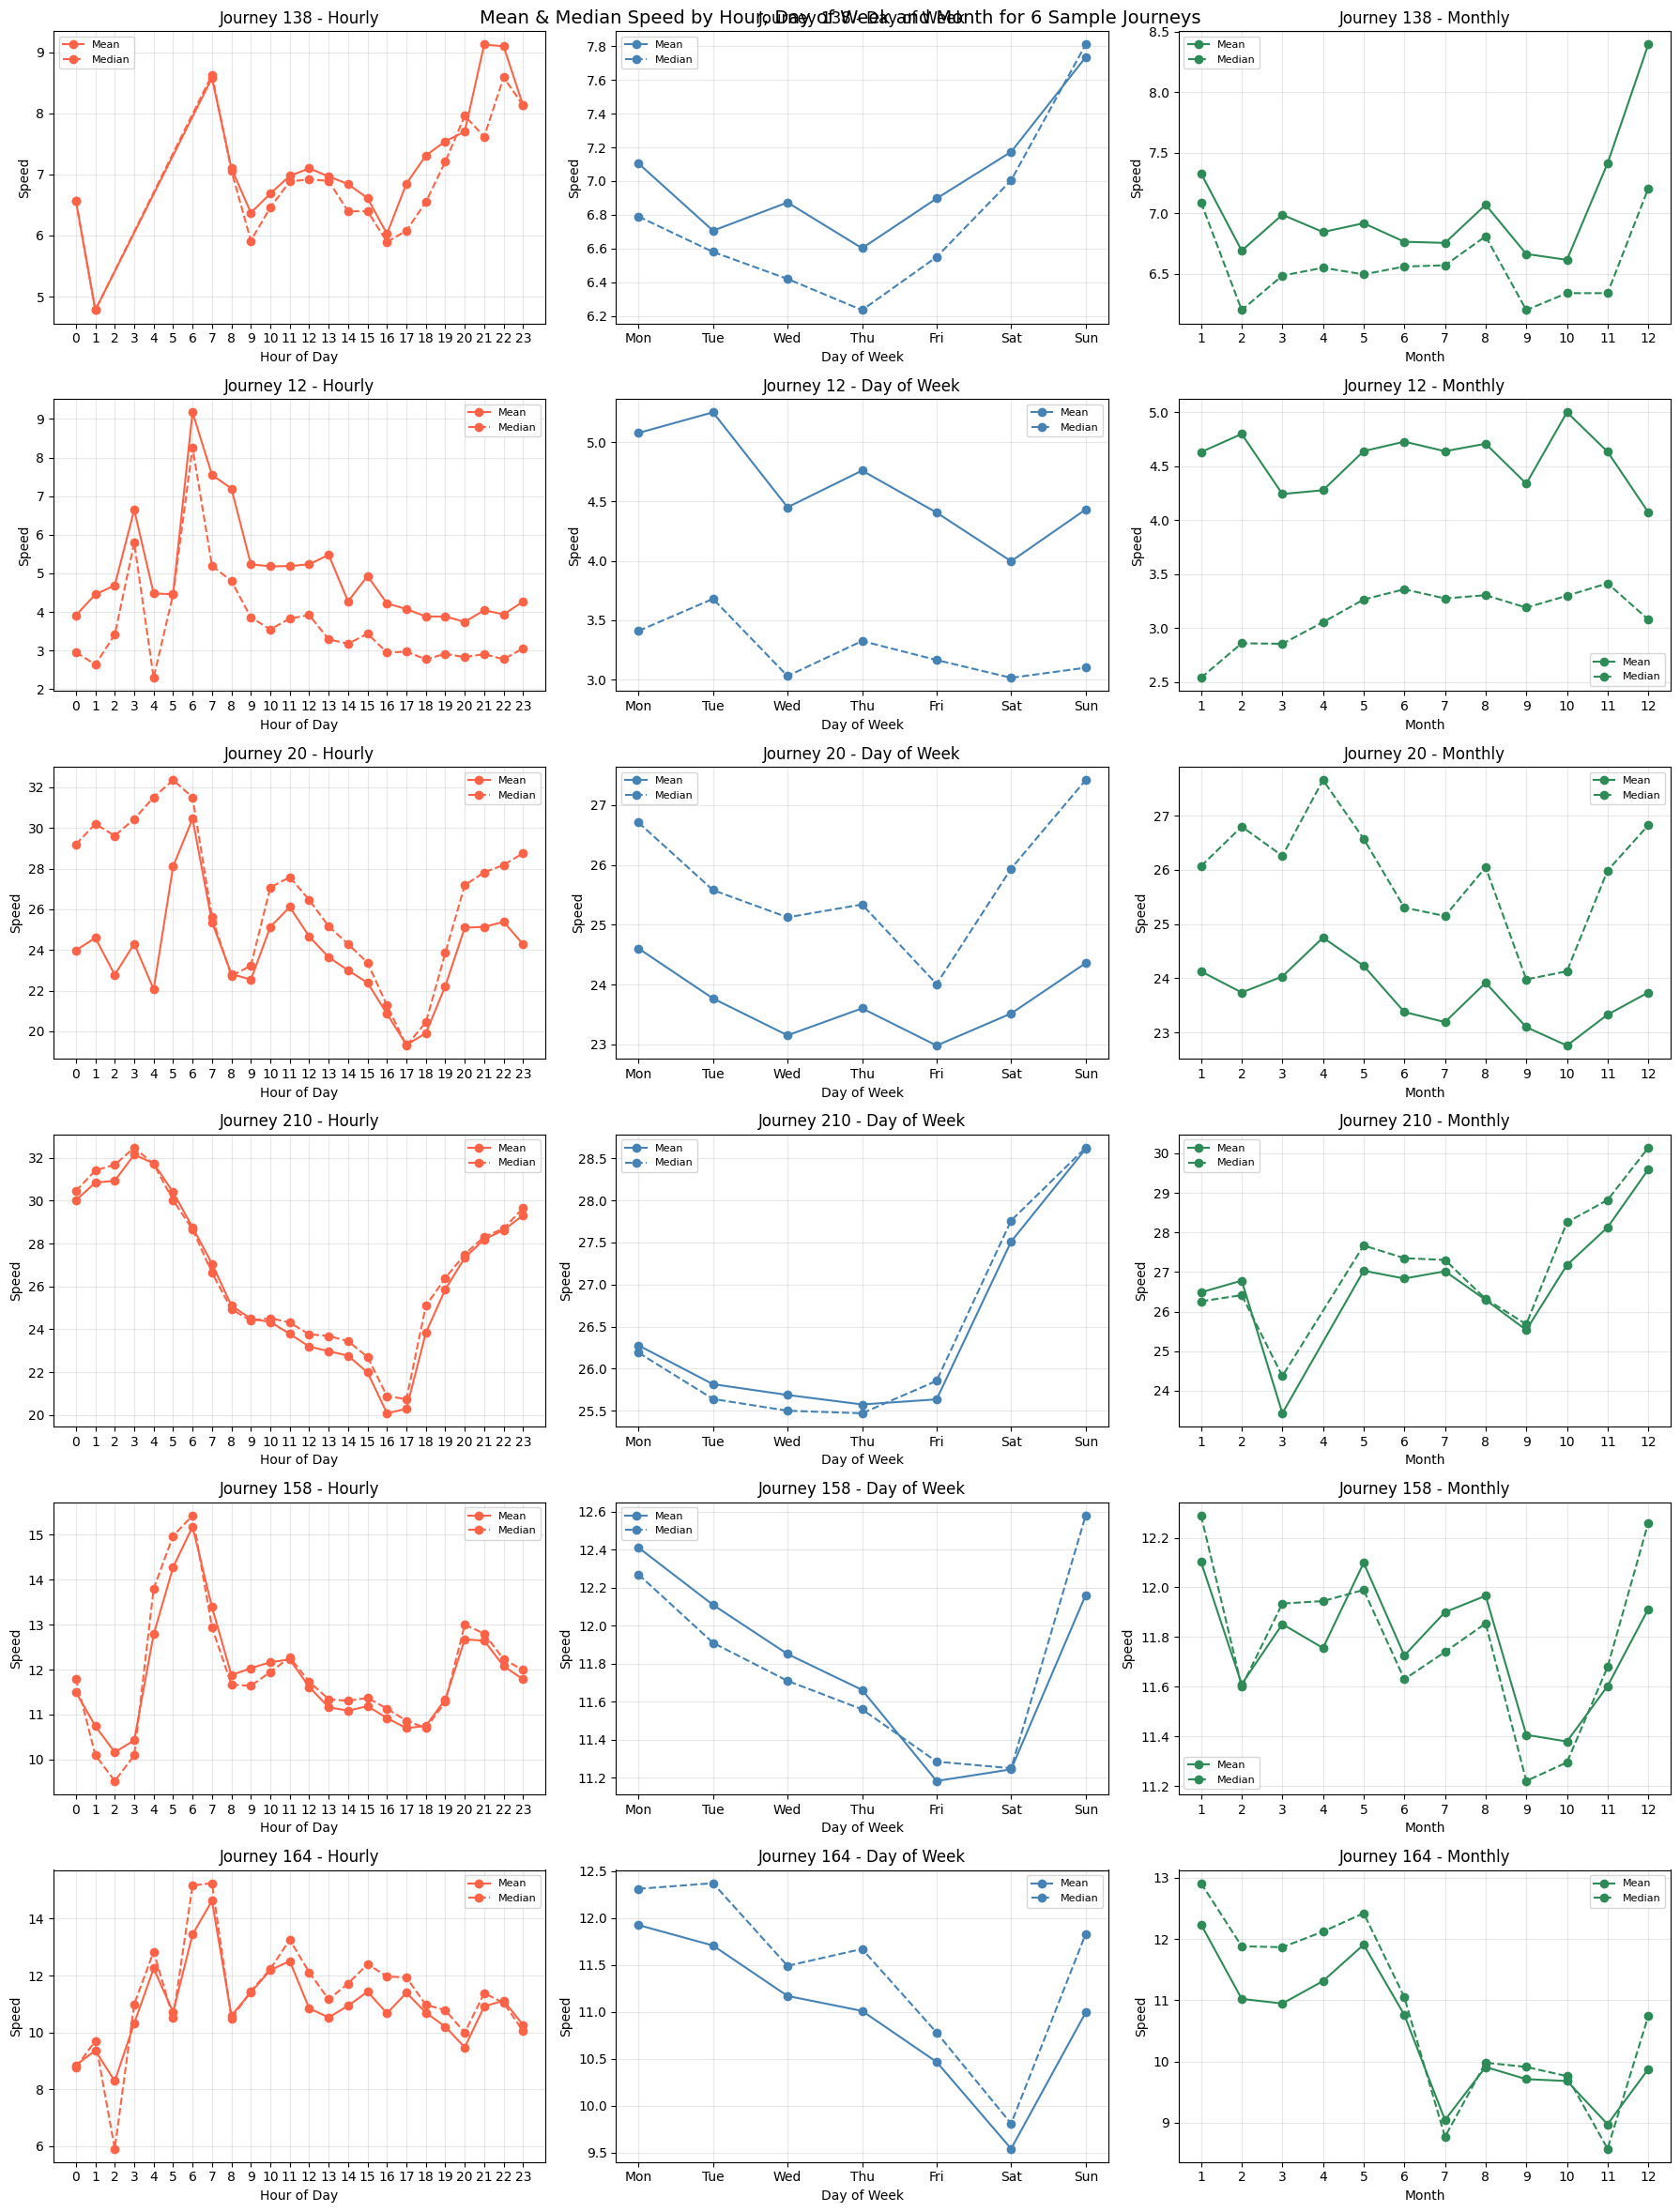

In [ ]:
sample_ids = random.sample(list(counts_df['JOURNEY_LINK_ID'].unique()), 6)

fig, axes = plt.subplots(6, 3, figsize=(18, 24))

for i, journey_id in enumerate(sample_ids):
    group = counts_df[counts_df['JOURNEY_LINK_ID'] == journey_id]

    # Hourly
    hourly = group.groupby('HOUR')['SPEED'].agg(['mean', 'median']).reset_index()
    axes[i, 0].plot(hourly['HOUR'], hourly['mean'], marker='o', color='tomato', label='Mean')
    axes[i, 0].plot(hourly['HOUR'], hourly['median'], marker='o', color='tomato', linestyle='--', label='Median')
    axes[i, 0].set_xlabel('Hour of Day')
    axes[i, 0].set_ylabel('Speed')
    axes[i, 0].set_title(f'Journey {journey_id} - Hourly')
    axes[i, 0].set_xticks(range(24))
    axes[i, 0].legend(fontsize=8)
    axes[i, 0].grid(True, alpha=0.3)

    # Day of week
    dow = group.groupby('DAY_OF_WEEK')['SPEED'].agg(['mean', 'median']).reset_index()
    day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    axes[i, 1].plot(dow['DAY_OF_WEEK'], dow['mean'], marker='o', color='steelblue', label='Mean')
    axes[i, 1].plot(dow['DAY_OF_WEEK'], dow['median'], marker='o', color='steelblue', linestyle='--', label='Median')
    axes[i, 1].set_xlabel('Day of Week')
    axes[i, 1].set_ylabel('Speed')
    axes[i, 1].set_title(f'Journey {journey_id} - Day of Week')
    axes[i, 1].set_xticks(range(7))
    axes[i, 1].set_xticklabels(day_labels)
    axes[i, 1].legend(fontsize=8)
    axes[i, 1].grid(True, alpha=0.3)

    # Monthly
    monthly = group.groupby('MONTH')['SPEED'].agg(['mean', 'median']).reset_index()
    axes[i, 2].plot(monthly['MONTH'], monthly['mean'], marker='o', color='seagreen', label='Mean')
    axes[i, 2].plot(monthly['MONTH'], monthly['median'], marker='o', color='seagreen', linestyle='--', label='Median')
    axes[i, 2].set_xlabel('Month')
    axes[i, 2].set_ylabel('Speed')
    axes[i, 2].set_title(f'Journey {journey_id} - Monthly')
    axes[i, 2].set_xticks(range(1, 13))
    axes[i, 2].legend(fontsize=8)
    axes[i, 2].grid(True, alpha=0.3)

plt.suptitle('Mean & Median Speed by Hour, Day of Week and Month for 6 Sample Journeys', fontsize=14)
plt.tight_layout()
plt.show()

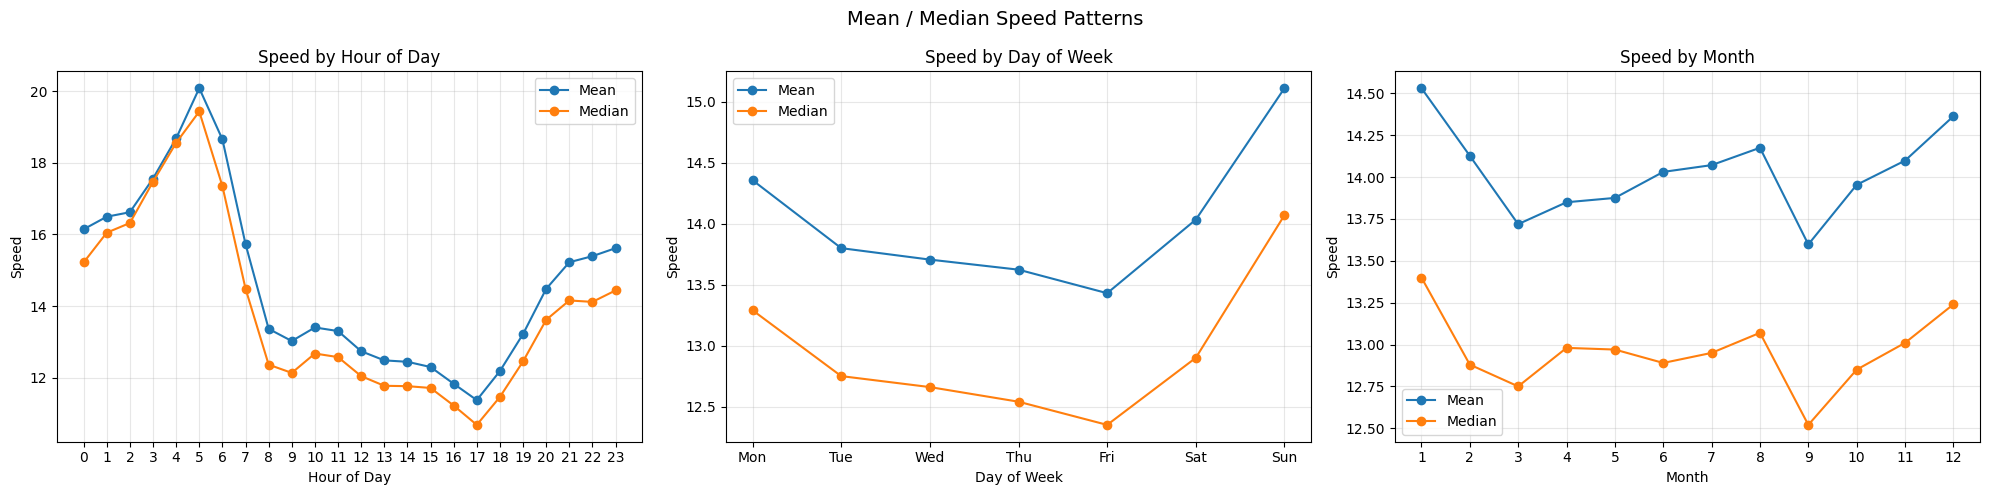

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Hourly
hourly_speed = counts_df.groupby('HOUR')['SPEED'].agg(['mean', 'median']).reset_index()
axes[0].plot(hourly_speed['HOUR'], hourly_speed['mean'], marker='o', label='Mean')
axes[0].plot(hourly_speed['HOUR'], hourly_speed['median'], marker='o', label='Median')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Speed')
axes[0].set_title('Speed by Hour of Day')
axes[0].set_xticks(range(24))
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Day of week
dow_speed = counts_df.groupby('DAY_OF_WEEK')['SPEED'].agg(['mean', 'median']).reset_index()
day_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
axes[1].plot(dow_speed['DAY_OF_WEEK'], dow_speed['mean'], marker='o', label='Mean')
axes[1].plot(dow_speed['DAY_OF_WEEK'], dow_speed['median'], marker='o', label='Median')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Speed')
axes[1].set_title('Speed by Day of Week')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Monthly
monthly_speed = counts_df.groupby('MONTH')['SPEED'].agg(['mean', 'median']).reset_index()
axes[2].plot(monthly_speed['MONTH'], monthly_speed['mean'], marker='o', label='Mean')
axes[2].plot(monthly_speed['MONTH'], monthly_speed['median'], marker='o', label='Median')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Speed')
axes[2].set_title('Speed by Month')
axes[2].set_xticks(range(1, 13))
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Mean / Median Speed Patterns', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats

# Hour of day
hourly_groups = [counts_df[counts_df['HOUR'] == h]['SPEED'].dropna().values for h in range(24)]
h_stat_hour, p_hour = stats.kruskal(*hourly_groups)

# Day of week
dow_groups = [counts_df[counts_df['DAY_OF_WEEK'] == d]['SPEED'].dropna().values for d in range(7)]
h_stat_dow, p_dow = stats.kruskal(*dow_groups)

# Month
monthly_groups = [counts_df[counts_df['MONTH'] == m]['SPEED'].dropna().values for m in range(1, 13)]
h_stat_month, p_month = stats.kruskal(*monthly_groups)

# Season
season_groups = [counts_df[counts_df['SEASON'] == s]['SPEED'].dropna().values for s in counts_df['SEASON'].cat.categories]
h_stat_season, p_season = stats.kruskal(*season_groups)

# Summary table
results = pd.DataFrame({
    'Category': ['Hour of Day', 'Day of Week', 'Month', 'Season'],
    'H-Statistic': [h_stat_hour, h_stat_dow, h_stat_month, h_stat_season],
    'P-Value': [p_hour, p_dow, p_month, p_season],
    'Significant': ['Yes' if p < 0.05 else 'No' for p in [p_hour, p_dow, p_month, p_season]]
})

print(results.to_string(index=False))

   Category  H-Statistic       P-Value Significant
Hour of Day 35778.983584  0.000000e+00         Yes
Day of Week  3219.452116  0.000000e+00         Yes
      Month   589.083014 3.028409e-119         Yes
     Season    44.753716  1.043775e-09         Yes


In [ ]:
# build the congestion factor over time